In [1]:
"""
# 02 · Modelos lineales en PyTorch

En este notebook vamos a construir y entrenar nuestro primer modelo en PyTorch.

El objetivo es entender cómo se combinan los conceptos vistos en el notebook anterior:

- tensores,
- "autograd",
- funciones de pérdida,
- optimizadores,
- loops de entrenamiento.

Vamos a trabajar con un problema simple de regresión lineal sintética:

y = 3x + 2 + ruido

La idea es que el modelo aprenda automáticamente los parámetros aproximados:

w \approx 3

b \approx 2

Este ejemplo es simple, pero contiene la estructura básica de casi cualquier entrenamiento en deep learning.
"""

'\n# 02 · Modelos lineales en PyTorch\n\nEn este notebook vamos a construir y entrenar nuestro primer modelo en PyTorch.\n\nEl objetivo es entender cómo se combinan los conceptos vistos en el notebook anterior:\n\n- tensores,\n- "autograd",\n- funciones de pérdida,\n- optimizadores,\n- loops de entrenamiento.\n\nVamos a trabajar con un problema simple de regresión lineal sintética:\n\ny = 3x + 2 + ruido\n\nLa idea es que el modelo aprenda automáticamente los parámetros aproximados:\n\nw \x07pprox 3\n\nb \x07pprox 2\n\nEste ejemplo es simple, pero contiene la estructura básica de casi cualquier entrenamiento en deep learning.\n'

In [2]:
# ------------------------------------------------------------
# 01 · Imports and general configuration
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
DATA_DIR = PROJECT_DIR / "data"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Selected device: cpu


In [3]:
"""
## 1. Generación de datos sintéticos

Para entender el entrenamiento de un modelo lineal, vamos a crear datos artificiales.
La relación verdadera será:

y = 3x + 2 + epsilon

donde:
- (x) es la variable de entrada,
- (3) es la pendiente real,
- (2) es el intercepto real,
- (epsilon) representa ruido aleatorio.
El modelo no conoce estos valores. Su tarea será aprenderlos a partir de los datos.
"""

'\n## 1. Generación de datos sintéticos\n\nPara entender el entrenamiento de un modelo lineal, vamos a crear datos artificiales.\n\nLa relación verdadera será:\n\ny = 3x + 2 + epsilon\n\ndonde:\n\n- (x) es la variable de entrada,\n- (3) es la pendiente real,\n- (2) es el intercepto real,\n- (epsilon) representa ruido aleatorio.\n\nEl modelo no conoce estos valores. Su tarea será aprenderlos a partir de los datos.\n'

In [4]:
# ------------------------------------------------------------
# 02 · Generate synthetic linear data
# ------------------------------------------------------------

n_samples = 100

x_np = np.linspace(-5, 5, n_samples).astype(np.float32)
noise_np = np.random.normal(loc=0.0, scale=2.0, size=n_samples).astype(np.float32)

true_w = 3.0
true_b = 2.0

y_np = true_w * x_np + true_b + noise_np

print("x shape:", x_np.shape)
print("y shape:", y_np.shape)

print("First 5 x values:", x_np[:5])
print("First 5 y values:", y_np[:5])

x shape: (100,)
y shape: (100,)
First 5 x values: [-5.        -4.8989897 -4.79798   -4.6969695 -4.5959597]
First 5 y values: [-12.006572 -12.973497 -11.098563  -9.044848 -12.256186]


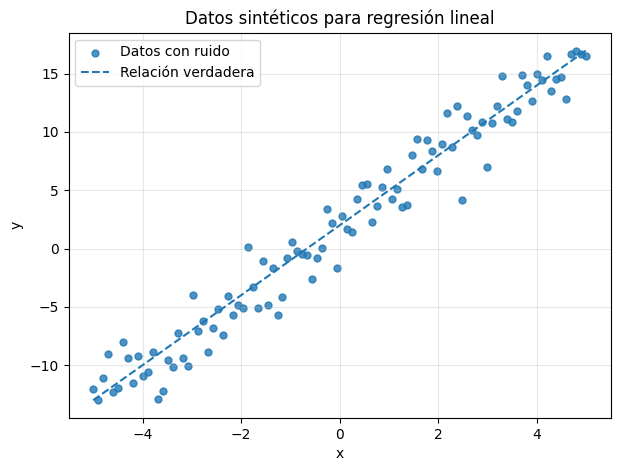

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\linear_regression_synthetic_data.png


In [5]:
# ------------------------------------------------------------
# 03 · Visualize synthetic data
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(x_np, y_np, s=25, alpha=0.8, label="Datos con ruido")
plt.plot(x_np, true_w * x_np + true_b, linestyle="--", label="Relación verdadera")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos sintéticos para regresión lineal")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "linear_regression_synthetic_data.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [6]:
"""
## 2. Conversión a tensores

PyTorch trabaja con tensores, por lo que necesitamos convertir nuestros datos de NumPy.

Además, es importante ajustar la forma ("shape") de los datos:

- "x" debe ser "(n_samples, 1)"
- "y" debe ser "(n_samples, 1)"

Esto es porque "nn.Linear" espera entradas en formato de matriz:

text
(batch_size, num_features)
"""

'\n## 2. Conversión a tensores\n\nPyTorch trabaja con tensores, por lo que necesitamos convertir nuestros datos de NumPy.\n\nAdemás, es importante ajustar la forma ("shape") de los datos:\n\n- "x" debe ser "(n_samples, 1)"\n- "y" debe ser "(n_samples, 1)"\n\nEsto es porque "nn.Linear" espera entradas en formato de matriz:\n\ntext\n(batch_size, num_features)\n'

In [7]:
# ------------------------------------------------------------
# 04 · Convert data to PyTorch tensors
# ------------------------------------------------------------

x = torch.from_numpy(x_np).view(-1, 1)
y = torch.from_numpy(y_np).view(-1, 1)

print("x tensor shape:", x.shape)
print("y tensor shape:", y.shape)

# Move to device (CPU in your case)
x = x.to(device)
y = y.to(device)

x tensor shape: torch.Size([100, 1])
y tensor shape: torch.Size([100, 1])


In [11]:
"""
## 3. Definición del modelo lineal

Vamos a usar "nn.Linear", que implementa:

y = Wx + b

En este caso:

- entrada: 1 feature (x)
- salida: 1 valor (y)

Por lo tanto:
"""


'\n## 3. Definición del modelo lineal\n\nVamos a usar "nn.Linear", que implementa:\n\ny = Wx + b\n\nEn este caso:\n\n- entrada: 1 feature (x)\n- salida: 1 valor (y)\n\nPor lo tanto:\n'

In [12]:
# ------------------------------------------------------------
# 05 · Define linear model
# ------------------------------------------------------------

model = nn.Linear(in_features=1, out_features=1)

model = model.to(device)

print(model)

Linear(in_features=1, out_features=1, bias=True)


In [13]:
# ------------------------------------------------------------
# 06 · Inspect initial parameters
# ------------------------------------------------------------

for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

weight: tensor([[-0.4869]])
bias: tensor([0.5873])


In [14]:
"""
## 4. Función de pérdida y optimizador

Para entrenar el modelo necesitamos:

### Función de pérdida

Usamos error cuadrático medio (MSE):

Loss = (y_{pred} - y_{true})^2

En PyTorch:

python
nn.MSELoss()
"""

'\n## 4. Función de pérdida y optimizador\n\nPara entrenar el modelo necesitamos:\n\n### Función de pérdida\n\nUsamos error cuadrático medio (MSE):\n\nLoss = (y_{pred} - y_{true})^2\n\nEn PyTorch:\n\npython\nnn.MSELoss()\n'

In [15]:
# ------------------------------------------------------------
# 07 · Loss function and optimizer
# ------------------------------------------------------------

criterion = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [16]:
"""
## 5. Loop de entrenamiento

El entrenamiento de un modelo en PyTorch sigue siempre una estructura similar:

1. Hacer la predicción ("forward pass").
2. Calcular la función de pérdida.
3. Limpiar gradientes anteriores.
4. Calcular nuevos gradientes con "backward()".
5. Actualizar los parámetros con el optimizador.

En código, el patrón típico es:

prediction = model(x)
loss = criterion(prediction, y)

optimizer.zero_grad()
loss.backward()
optimizer.step()
"""

'\n## 5. Loop de entrenamiento\n\nEl entrenamiento de un modelo en PyTorch sigue siempre una estructura similar:\n\n1. Hacer la predicción ("forward pass").\n2. Calcular la función de pérdida.\n3. Limpiar gradientes anteriores.\n4. Calcular nuevos gradientes con "backward()".\n5. Actualizar los parámetros con el optimizador.\n\nEn código, el patrón típico es:\n\nprediction = model(x)\nloss = criterion(prediction, y)\n\noptimizer.zero_grad()\nloss.backward()\noptimizer.step()\n'

In [17]:
# ------------------------------------------------------------
# 08 · Training loop
# ------------------------------------------------------------

n_epochs = 300
loss_history = []

for epoch in range(n_epochs):
    # Forward pass
    y_pred = model(x)

    # Compute loss
    loss = criterion(y_pred, y)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Update parameters
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    # Print progress
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1:03d}/{n_epochs}] - Loss: {loss.item():.4f}")

Epoch [050/300] - Loss: 3.4601
Epoch [100/300] - Loss: 3.2862
Epoch [150/300] - Loss: 3.2631
Epoch [200/300] - Loss: 3.2601
Epoch [250/300] - Loss: 3.2597
Epoch [300/300] - Loss: 3.2596


In [18]:
# ------------------------------------------------------------
# 09 · Inspect learned parameters
# ------------------------------------------------------------

learned_w = model.weight.item()
learned_b = model.bias.item()

print(f"True weight     : {true_w:.4f}")
print(f"Learned weight  : {learned_w:.4f}")

print(f"\nTrue bias       : {true_b:.4f}")
print(f"Learned bias    : {learned_b:.4f}")

True weight     : 3.0000
Learned weight  : 3.0276

True bias       : 2.0000
Learned bias    : 1.7895


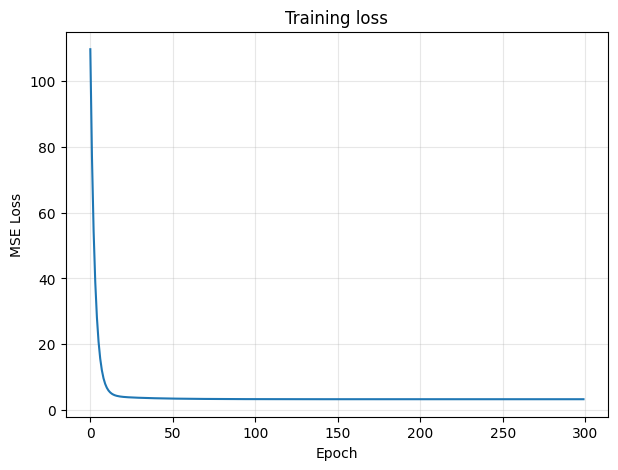

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\linear_regression_training_loss.png


In [19]:
# ------------------------------------------------------------
# 10 · Plot training loss
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training loss")
plt.grid(alpha=0.3)

out = FIGURES_DIR / "linear_regression_training_loss.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

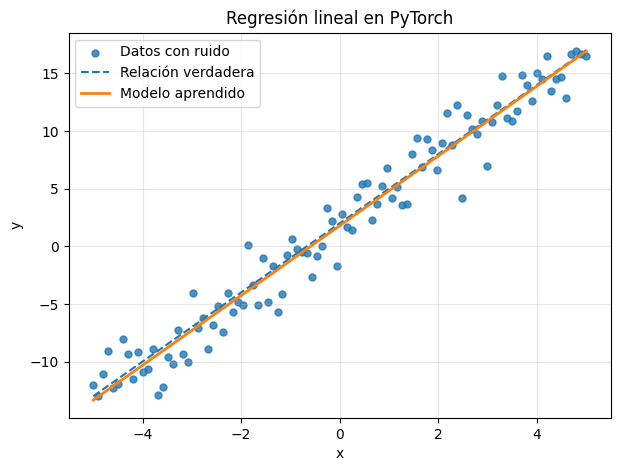

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\linear_regression_learned_model.png


In [20]:
# ------------------------------------------------------------
# 11 · Compare learned model with true relationship
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    y_pred = model(x).cpu().numpy()

plt.figure(figsize=(7, 5))
plt.scatter(x_np, y_np, s=25, alpha=0.8, label="Datos con ruido")
plt.plot(x_np, true_w * x_np + true_b, linestyle="--", label="Relación verdadera")
plt.plot(x_np, y_pred, linewidth=2, label="Modelo aprendido")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regresión lineal en PyTorch")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "linear_regression_learned_model.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [21]:
"""
## 6. Interpretación del resultado

El modelo aprendió una relación lineal muy cercana a la función original usada para generar los datos.

La diferencia entre los parámetros verdaderos y los parámetros aprendidos se debe principalmente al ruido agregado.

Este ejemplo muestra la estructura mínima de un entrenamiento en PyTorch:

text
datos → modelo → pérdida → gradientes → actualización de parámetros

## 7. Conexión con Deep Learning

Aunque este ejemplo es una regresión lineal simple, contiene todos los componentes fundamentales de un modelo de deep learning:

- Un modelo con parámetros ("nn.Module")
- Una función de pérdida
- Un optimizador
- Un loop de entrenamiento
- Gradientes automáticos ("autograd")

En redes neuronales más complejas, lo único que cambia es:

- la arquitectura del modelo (más capas, no linealidades),
- la cantidad de parámetros,
- el tipo de datos (imágenes, volúmenes, etc).

El flujo general permanece exactamente igual.
"""

'\n## 6. Interpretación del resultado\n\nEl modelo aprendió una relación lineal muy cercana a la función original usada para generar los datos.\n\nLa diferencia entre los parámetros verdaderos y los parámetros aprendidos se debe principalmente al ruido agregado.\n\nEste ejemplo muestra la estructura mínima de un entrenamiento en PyTorch:\n\ntext\ndatos → modelo → pérdida → gradientes → actualización de parámetros\n\n## 7. Conexión con Deep Learning\n\nAunque este ejemplo es una regresión lineal simple, contiene todos los componentes fundamentales de un modelo de deep learning:\n\n- Un modelo con parámetros ("nn.Module")\n- Una función de pérdida\n- Un optimizador\n- Un loop de entrenamiento\n- Gradientes automáticos ("autograd")\n\nEn redes neuronales más complejas, lo único que cambia es:\n\n- la arquitectura del modelo (más capas, no linealidades),\n- la cantidad de parámetros,\n- el tipo de datos (imágenes, volúmenes, etc).\n\nEl flujo general permanece exactamente igual.\n'

In [22]:
# ------------------------------------------------------------
# 12 · Save trained model
# ------------------------------------------------------------

model_path = MODELS_DIR / "linear_regression_model.pt"

torch.save(model.state_dict(), model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\models\linear_regression_model.pt


In [23]:
"""
# Conclusión final

Este notebook introduce el flujo completo de entrenamiento en PyTorch usando un modelo lineal.

La importancia de este ejemplo no está en la complejidad del modelo, sino en la comprensión del proceso:

- cómo se construyen los modelos,
- cómo se calculan los gradientes,
- cómo se actualizan los parámetros,
- cómo se evalúan los resultados.

Este conocimiento es directamente transferible a:

- redes neuronales multicapa (MLP),
- redes convolucionales (CNN),
- modelos para imágenes científicas,
- modelos 3D para volúmenes tomográficos.

En el próximo notebook avanzaremos hacia modelos no lineales usando redes neuronales.
"""

'\n# Conclusión final\n\nEste notebook introduce el flujo completo de entrenamiento en PyTorch usando un modelo lineal.\n\nLa importancia de este ejemplo no está en la complejidad del modelo, sino en la comprensión del proceso:\n\n- cómo se construyen los modelos,\n- cómo se calculan los gradientes,\n- cómo se actualizan los parámetros,\n- cómo se evalúan los resultados.\n\nEste conocimiento es directamente transferible a:\n\n- redes neuronales multicapa (MLP),\n- redes convolucionales (CNN),\n- modelos para imágenes científicas,\n- modelos 3D para volúmenes tomográficos.\n\nEn el próximo notebook avanzaremos hacia modelos no lineales usando redes neuronales.\n'

In [24]:
# ------------------------------------------------------------
# 14 · End of notebook
# ------------------------------------------------------------

print("Notebook 02 completed successfully.")

Notebook 02 completed successfully.
